# 01 — Exploratory Data Analysis: Metro Interstate Traffic Volume

**Goal of this notebook:** understand the dataset well enough to (1) trust it before modeling, and (2) answer the three business questions defined in the project brief.

**Manual data-quality checklist** (done step by step, not via an automated profiling tool — the point is to learn *how* to diagnose a dataset, not just get a report):
1. Shape, dtypes
2. Missing values
3. Duplicates
4. `.describe()` ranges checked against real-world domain plausibility
5. Categorical cardinality
6. Target variable distribution
7. Temporal continuity (since this is hourly time-series data)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/raw/Metro_Interstate_Traffic_Volume.csv')
df.shape


(48204, 9)

## Checklist step 1: dtypes

Before anything else, check what pandas *thinks* each column is — this often exposes problems on its own (e.g. a numeric column stored as text because of a stray character somewhere).

In [2]:
df.dtypes


traffic_volume           int64
holiday                    str
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main               str
weather_description        str
date_time                  str
dtype: object

## Checklist step 2: missing values

`.isna().sum()` counts nulls per column. Important: a high count here doesn't automatically mean "bad data" — we have to interpret *why* a column is missing before deciding how to handle it.

In [3]:
df.isna().sum()


traffic_volume             0
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
dtype: int64

## Checklist step 3: duplicates

Two different kinds of duplication to check separately: (a) fully identical rows, and (b) rows that share the same `date_time` but differ elsewhere — the second is easy to miss if you only check `.duplicated()` on the whole row.

In [4]:
print('Fully identical duplicate rows:', df.duplicated().sum())
print('Rows sharing a date_time with another row:', df['date_time'].duplicated().sum())


Fully identical duplicate rows: 17
Rows sharing a date_time with another row: 7629


## Checklist step 4: `.describe()` vs. real-world domain plausibility

This is the step no automated tool can do for you — you need to know what's physically possible in the real world and check the min/max against it. A statistical outlier detector will flag *unusual* values; it doesn't know that 0 Kelvin is impossible unless you tell it.

In [5]:
df.describe()


,traffic_volume,temp,rain_1h,snow_1h,clouds_all
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231
std,1986.860670,13.338232,44.789133,0.008168,39.015750
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000


## Checklist step 5: categorical cardinality

For each text/categorical column, check how many distinct values it has and what they are. This matters for later encoding decisions (one-hot vs. something smarter) and can itself expose data-quality issues (e.g. "New York" vs "new york " vs "NY" all meaning the same thing).

In [6]:
categorical_cols = ['holiday', 'weather_main', 'weather_description']
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(sorted(df[col].dropna().unique()))
    print()


holiday: 11 unique values
['Christmas Day', 'Columbus Day', 'Independence Day', 'Labor Day', 'Martin Luther King Jr Day', 'Memorial Day', 'New Years Day', 'State Fair', 'Thanksgiving Day', 'Veterans Day', 'Washingtons Birthday']

weather_main: 11 unique values
['Clear', 'Clouds', 'Drizzle', 'Fog', 'Haze', 'Mist', 'Rain', 'Smoke', 'Snow', 'Squall', 'Thunderstorm']

weather_description: 38 unique values
['SQUALLS', 'Sky is Clear', 'broken clouds', 'drizzle', 'few clouds', 'fog', 'freezing rain', 'haze', 'heavy intensity drizzle', 'heavy intensity rain', 'heavy snow', 'light intensity drizzle', 'light intensity shower rain', 'light rain', 'light rain and snow', 'light shower snow', 'light snow', 'mist', 'moderate rain', 'overcast clouds', 'proximity shower rain', 'proximity thunderstorm', 'proximity thunderstorm with drizzle', 'proximity thunderstorm with rain', 'scattered clouds', 'shower drizzle', 'shower snow', 'sky is clear', 'sleet', 'smoke', 'snow', 'thunderstorm', 'thunderstorm wit

## Checklist step 6: target variable distribution

Before modeling, understand the shape of what we're predicting: is it symmetric or skewed? Are there suspicious spikes (e.g. too many zeros)? This affects both model choice and whether a transformation (like log) is worth trying.

Skewness: -0.08938135143647917
Rows with traffic_volume == 0: 2
Rows with traffic_volume < 50: 57


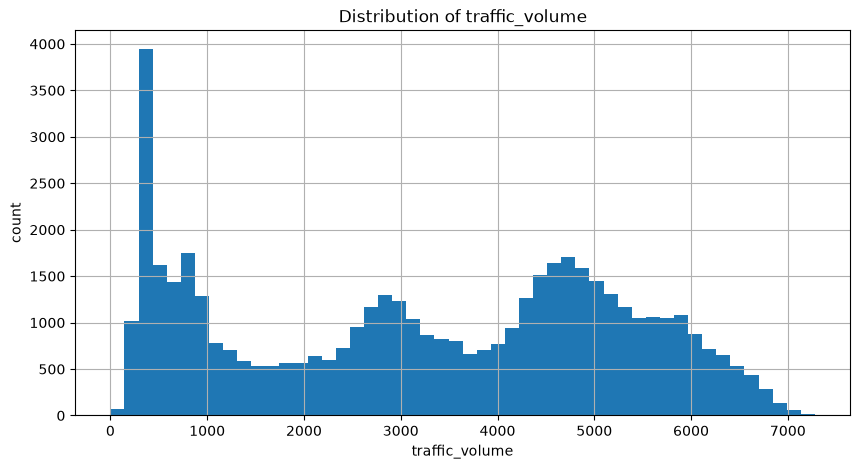

In [7]:
print('Skewness:', df['traffic_volume'].skew())
print('Rows with traffic_volume == 0:', (df['traffic_volume'] == 0).sum())
print('Rows with traffic_volume < 50:', (df['traffic_volume'] < 50).sum())

fig, ax = plt.subplots()
df['traffic_volume'].hist(bins=50, ax=ax)
ax.set_xlabel('traffic_volume')
ax.set_ylabel('count')
ax.set_title('Distribution of traffic_volume')
plt.savefig('../reports/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()


### Verifying the "day vs. night" hypothesis (don't just assume — check)

The bimodal shape above looks like it could be day/night traffic, but that's a guess until checked against the actual `date_time` column. Extracting the hour and looking at mean traffic per hour will confirm or kill this hypothesis.

date_time
0      835.0
1      516.0
2      388.0
3      371.0
4      703.0
5     2095.0
6     4141.0
7     4740.0
8     4587.0
9     4385.0
10    4185.0
11    4466.0
12    4718.0
13    4715.0
14    4932.0
15    5241.0
16    5664.0
17    5310.0
18    4264.0
19    3276.0
20    2835.0
21    2669.0
22    2199.0
23    1469.0
Name: traffic_volume, dtype: float64


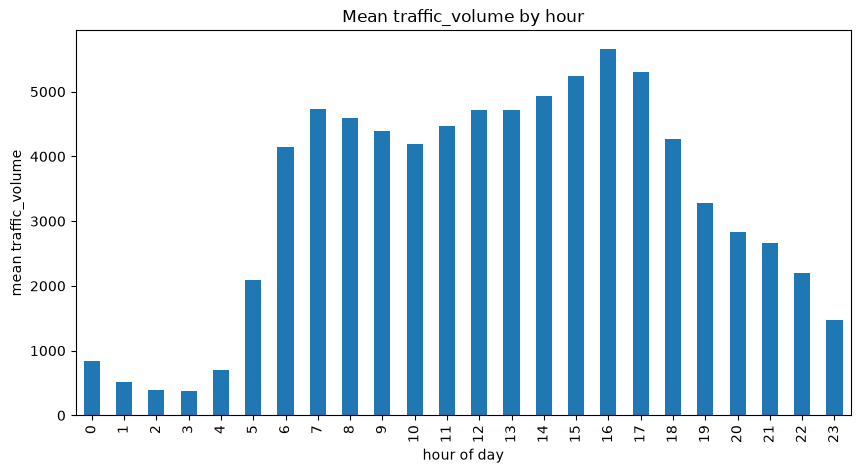

In [8]:
hour = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M').dt.hour
mean_by_hour = df['traffic_volume'].groupby(hour).mean()
print(mean_by_hour.round(0))

fig, ax = plt.subplots()
mean_by_hour.plot(kind='bar', ax=ax)
ax.set_xlabel('hour of day')
ax.set_ylabel('mean traffic_volume')
ax.set_title('Mean traffic_volume by hour')
plt.savefig('../reports/traffic_by_hour.png', dpi=100, bbox_inches='tight')
plt.show()


## Checklist step 7: temporal continuity

This is hourly data — the last check is whether every hour between the first and last timestamp is actually present, or whether there are gaps (e.g. a sensor outage). Gaps matter for time-based feature engineering and for knowing how much we can trust hour-to-hour comparisons.

In [9]:
date_parsed = pd.to_datetime(df['date_time'], format='%d-%m-%Y %H:%M')

full_range = pd.date_range(start=date_parsed.min(), end=date_parsed.max(), freq='h')
missing_hours = full_range.difference(date_parsed)

print('First timestamp:', date_parsed.min())
print('Last timestamp:', date_parsed.max())
print('Expected hourly timestamps in this range:', len(full_range))
print('Unique timestamps actually present:', date_parsed.nunique())
print('Missing hours:', len(missing_hours))


First timestamp: 2012-10-02 09:00:00
Last timestamp: 2018-09-30 23:00:00
Expected hourly timestamps in this range: 52551
Unique timestamps actually present: 40575
Missing hours: 11976
